In [1]:
import os

# Set working directory to Churn Prediction folder
os.chdir('..')
print("Working directory:", os.getcwd())

# Create all folders
folders = ['data', 'models', 'output', 'src', 
           'notebooks', 'dashboard', 'screenshots']
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}/")

print("\nAll folders ready.")
print("Now put WA_Fn-UseC_-Telco-Customer-Churn.csv in the data/ folder")

Working directory: C:\Users\navya\OneDrive\Desktop\Churn Prediction
Created: data/
Created: models/
Created: output/
Created: src/
Created: notebooks/
Created: dashboard/
Created: screenshots/

All folders ready.
Now put WA_Fn-UseC_-Telco-Customer-Churn.csv in the data/ folder


In [2]:
import os

if os.path.exists('data/WA_Fn-UseC_-Telco-Customer-Churn.csv'):
    import pandas as pd
    df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset found.")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
else:
    print("Dataset NOT found.")
    print("Please put the CSV file in the data/ folder.")

Dataset found.
Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install xgboost shap sqlalchemy openpyxl
!pip install imbalanced-learn joblib
print("All libraries installed.")

All libraries installed.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.cluster import KMeans
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total customers:  {df.shape[0]}")
print(f"Total features:   {df.shape[1]}")
print(f"\nChurn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")

DATASET OVERVIEW
Total customers:  7043
Total features:   21

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%

Missing values: 0


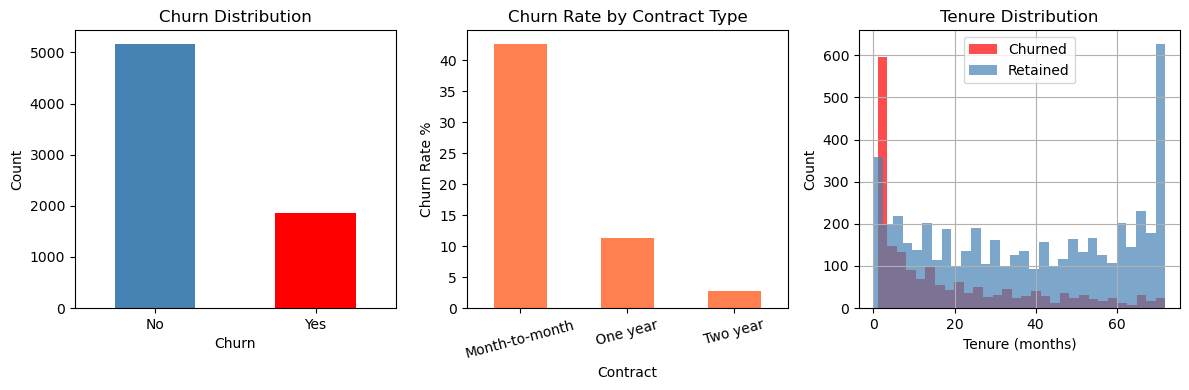

Saved: output/churn_distribution.png


In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['Churn'].value_counts().plot(kind='bar',
    color=['steelblue', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 3, 2)
churn_by_contract = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100)
churn_by_contract.plot(kind='bar', color='coral')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract')
plt.ylabel('Churn Rate %')
plt.xticks(rotation=15)

plt.subplot(1, 3, 3)
df[df['Churn']=='Yes']['tenure'].hist(
    bins=30, color='red', alpha=0.7, label='Churned')
df[df['Churn']=='No']['tenure'].hist(
    bins=30, color='steelblue', alpha=0.7, label='Retained')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.savefig('output/churn_distribution.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/churn_distribution.png")

In [8]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///churn.db')
df.to_sql('customers', engine,
    if_exists='replace', index=False)
print("Data loaded into SQLite database.")

# Query 1 — Churn rate by contract
query1 = """
SELECT Contract,
       COUNT(*) AS total_customers,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)
             / COUNT(*), 1) AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""
result1 = pd.read_sql(query1, engine)
print("\nChurn Rate by Contract Type:")
print(result1.to_string(index=False))

# Query 2 — Average charges by churn
query2 = """
SELECT Churn,
       ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
       ROUND(AVG(tenure), 1) AS avg_tenure_months,
       COUNT(*) AS total_customers
FROM customers
GROUP BY Churn
"""
result2 = pd.read_sql(query2, engine)
print("\nAverage Charges and Tenure by Churn:")
print(result2.to_string(index=False))

# Query 3 — Churn by internet service
query3 = """
SELECT InternetService,
       COUNT(*) AS total,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)
             / COUNT(*), 1) AS churn_rate_pct
FROM customers
GROUP BY InternetService
ORDER BY churn_rate_pct DESC
"""
result3 = pd.read_sql(query3, engine)
print("\nChurn Rate by Internet Service:")
print(result3.to_string(index=False))

# Query 4 — Churn by senior citizen
query4 = """
SELECT SeniorCitizen,
       COUNT(*) AS total,
       SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
       ROUND(100.0 * SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)
             / COUNT(*), 1) AS churn_rate_pct
FROM customers
GROUP BY SeniorCitizen
ORDER BY churn_rate_pct DESC
"""
result4 = pd.read_sql(query4, engine)
print("\nChurn Rate by Senior Citizen:")
print(result4.to_string(index=False))

# Save results
result1.to_csv('output/sql_churn_by_contract.csv', index=False)
result2.to_csv('output/sql_churn_by_charges.csv', index=False)
result3.to_csv('output/sql_churn_by_internet.csv', index=False)
result4.to_csv('output/sql_churn_by_senior.csv', index=False)
print("\nAll SQL results saved to output/")

Data loaded into SQLite database.

Churn Rate by Contract Type:
      Contract  total_customers  churned  churn_rate_pct
Month-to-month             3875     1655            42.7
      One year             1473      166            11.3
      Two year             1695       48             2.8

Average Charges and Tenure by Churn:
Churn  avg_monthly_charges  avg_tenure_months  total_customers
   No                61.27               37.6             5174
  Yes                74.44               18.0             1869

Churn Rate by Internet Service:
InternetService  total  churned  churn_rate_pct
    Fiber optic   3096     1297            41.9
            DSL   2421      459            19.0
             No   1526      113             7.4

Churn Rate by Senior Citizen:
 SeniorCitizen  total  churned  churn_rate_pct
             1   1142      476            41.7
             0   5901     1393            23.6

All SQL results saved to output/


In [9]:
df2 = df.copy()

# Fix TotalCharges
df2['TotalCharges'] = pd.to_numeric(
    df2['TotalCharges'], errors='coerce')
df2['TotalCharges'].fillna(
    df2['TotalCharges'].median(), inplace=True)

# New feature: charges per tenure month
df2['charges_per_tenure'] = df2['MonthlyCharges'] / (
    df2['tenure'] + 1)

# New feature: number of services
service_cols = ['PhoneService', 'MultipleLines',
                'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df2['service_count'] = df2[service_cols].apply(
    lambda row: sum(row == 'Yes'), axis=1)

# New feature: contract risk score
contract_map = {
    'Month-to-month': 2,
    'One year': 1,
    'Two year': 0
}
df2['contract_risk'] = df2['Contract'].map(contract_map)

# New feature: is senior with no support
df2['senior_no_support'] = (
    (df2['SeniorCitizen'] == 1) &
    (df2['TechSupport'] == 'No')).astype(int)

# New feature: high spender
df2['high_spender'] = (
    df2['MonthlyCharges'] > df2['MonthlyCharges'].median()
).astype(int)

print("=" * 50)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 50)
print(f"\nNew features created:")
print(f"  charges_per_tenure — avg: {df2['charges_per_tenure'].mean():.2f}")
print(f"  service_count      — avg: {df2['service_count'].mean():.2f} services")
print(f"  contract_risk      — {df2['contract_risk'].value_counts().to_dict()}")
print(f"  senior_no_support  — {df2['senior_no_support'].sum()} customers")
print(f"  high_spender       — {df2['high_spender'].sum()} customers")
print(f"\nDataset shape: {df2.shape}")

FEATURE ENGINEERING COMPLETE

New features created:
  charges_per_tenure — avg: 5.77
  service_count      — avg: 3.36 services
  contract_risk      — {2: 3875, 0: 1695, 1: 1473}
  senior_no_support  — 830 customers
  high_spender       — 3515 customers

Dataset shape: (7043, 26)


In [10]:
# Encode binary Yes/No columns
binary_cols = ['Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df2[col] = (df2[col] == 'Yes').astype(int)

# Encode gender
df2['gender'] = (df2['gender'] == 'Male').astype(int)

# One-hot encode remaining categoricals
cat_cols = ['MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']
df2 = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

# Drop customerID
df2.drop('customerID', axis=1, inplace=True)

print("=" * 50)
print("ENCODING COMPLETE")
print("=" * 50)
print(f"Shape after encoding: {df2.shape}")
print(f"\nAll features:")
for i, col in enumerate(df2.columns, 1):
    print(f"  {i:2}. {col}")

ENCODING COMPLETE
Shape after encoding: (7043, 36)

All features:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. PaperlessBilling
   8. MonthlyCharges
   9. TotalCharges
  10. Churn
  11. charges_per_tenure
  12. service_count
  13. contract_risk
  14. senior_no_support
  15. high_spender
  16. MultipleLines_No phone service
  17. MultipleLines_Yes
  18. InternetService_Fiber optic
  19. InternetService_No
  20. OnlineSecurity_No internet service
  21. OnlineSecurity_Yes
  22. OnlineBackup_No internet service
  23. OnlineBackup_Yes
  24. DeviceProtection_No internet service
  25. DeviceProtection_Yes
  26. TechSupport_No internet service
  27. TechSupport_Yes
  28. StreamingTV_No internet service
  29. StreamingTV_Yes
  30. StreamingMovies_No internet service
  31. StreamingMovies_Yes
  32. Contract_One year
  33. Contract_Two year
  34. PaymentMethod_Credit card (automatic)
  35. PaymentMethod_Electronic check
  36. PaymentMethod_

In [11]:
X = df2.drop('Churn', axis=1)
y = df2['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("=" * 50)
print("TRAIN TEST SPLIT")
print("=" * 50)
print(f"Training set:      {X_train.shape}")
print(f"Test set:          {X_test.shape}")
print(f"Training features: {X_train.shape[1]}")
print(f"\nChurn in training: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Churn in test:     {y_test.sum()} ({y_test.mean()*100:.1f}%)")

TRAIN TEST SPLIT
Training set:      (5634, 35)
Test set:          (1409, 35)
Training features: 35

Churn in training: 1495 (26.5%)
Churn in test:     374 (26.5%)


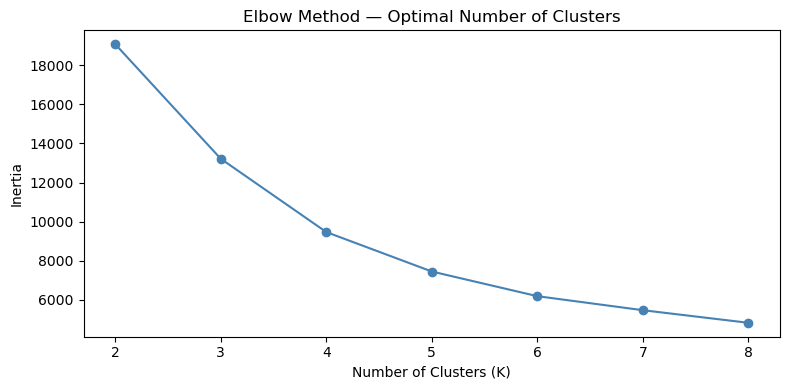

Saved: output/elbow_method.png

Customer Segments:
         Churn Rate  Avg Tenure  Avg Monthly  Avg Services
segment                                                   
0              14.0       60.11        91.59          5.75
1              67.0        1.80        69.49          2.27
2              37.0       22.64        77.52          3.65
3              13.0       27.96        26.95          1.35


In [12]:
seg_features = ['tenure', 'MonthlyCharges',
                'TotalCharges', 'service_count',
                'charges_per_tenure']

X_seg = df2[seg_features].copy()
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

# Find optimal k using elbow method
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_seg_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('output/elbow_method.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/elbow_method.png")

# Apply K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df2['segment'] = km_final.fit_predict(X_seg_scaled)

# Analyze segments
seg_analysis = df2.groupby('segment').agg({
    'Churn': 'mean',
    'tenure': 'mean',
    'MonthlyCharges': 'mean',
    'service_count': 'mean'
}).round(2)
seg_analysis.columns = ['Churn Rate', 'Avg Tenure',
                         'Avg Monthly', 'Avg Services']
seg_analysis['Churn Rate'] = (
    seg_analysis['Churn Rate'] * 100).round(1)
print("\nCustomer Segments:")
print(seg_analysis)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'models/scaler.pkl')
print("Scaler saved to models/scaler.pkl")
print(f"Features scaled: {X_train.shape[1]}")

Scaler saved to models/scaler.pkl
Features scaled: 35


In [14]:
print("Training Logistic Regression...")

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_prob)

print("\nLogistic Regression Results:")
print(classification_report(y_test, lr_pred,
    target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {lr_auc:.4f}")

Training Logistic Regression...

Logistic Regression Results:
              precision    recall  f1-score   support

    Retained       0.90      0.73      0.80      1035
     Churned       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8462


In [15]:
print("Training Gradient Boosting...")

gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
gb_auc = roc_auc_score(y_test, gb_prob)

print("\nGradient Boosting Results:")
print(classification_report(y_test, gb_pred,
    target_names=['Retained', 'Churned']))
print(f"ROC-AUC: {gb_auc:.4f}")

print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")
print(f"Gradient Boosting ROC-AUC:   {gb_auc:.4f}")
print(f"\nBest model: {'Gradient Boosting' if gb_auc > lr_auc else 'Logistic Regression'}")

Training Gradient Boosting...

Gradient Boosting Results:
              precision    recall  f1-score   support

    Retained       0.83      0.89      0.86      1035
     Churned       0.62      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8311

MODEL COMPARISON
Logistic Regression ROC-AUC: 0.8462
Gradient Boosting ROC-AUC:   0.8311

Best model: Logistic Regression


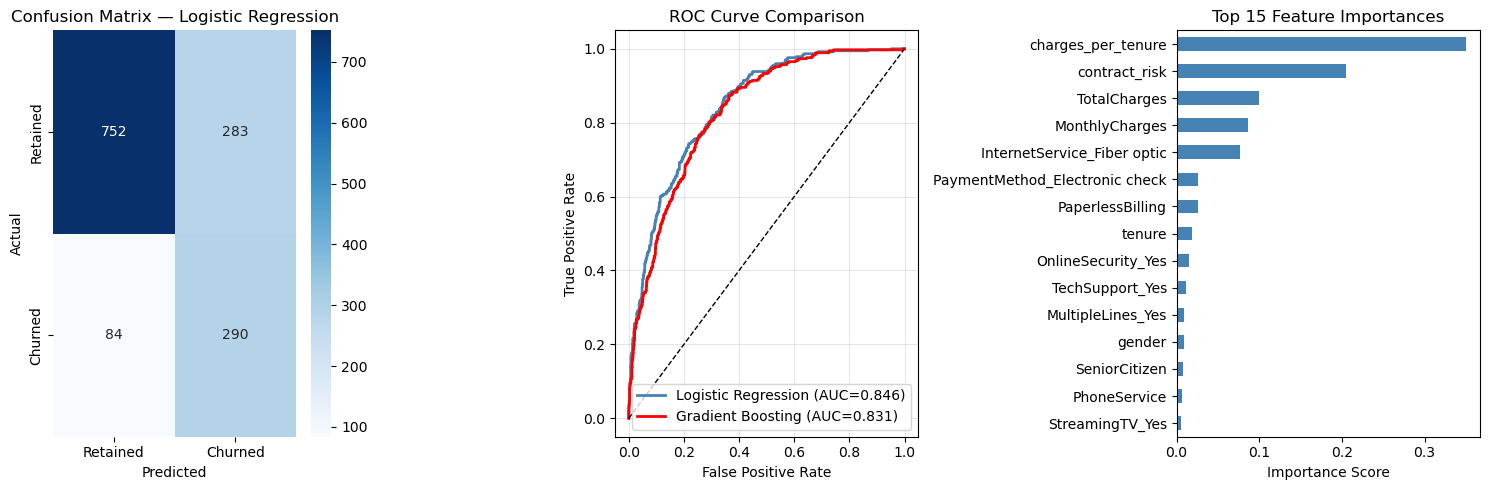

Saved: output/model_evaluation.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion Matrix — Logistic Regression
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
axes[1].plot(fpr_lr, tpr_lr,
    label=f'Logistic Regression (AUC={lr_auc:.3f})',
    color='steelblue', linewidth=2)
axes[1].plot(fpr_gb, tpr_gb,
    label=f'Gradient Boosting (AUC={gb_auc:.3f})',
    color='red', linewidth=2)
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve Comparison')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature Importance — Gradient Boosting
feat_imp = pd.Series(
    gb.feature_importances_,
    index=X_test.columns
).sort_values(ascending=True).tail(15)
feat_imp.plot(kind='barh', color='steelblue', ax=axes[2])
axes[2].set_title('Top 15 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('output/model_evaluation.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/model_evaluation.png")

Calculating SHAP values...


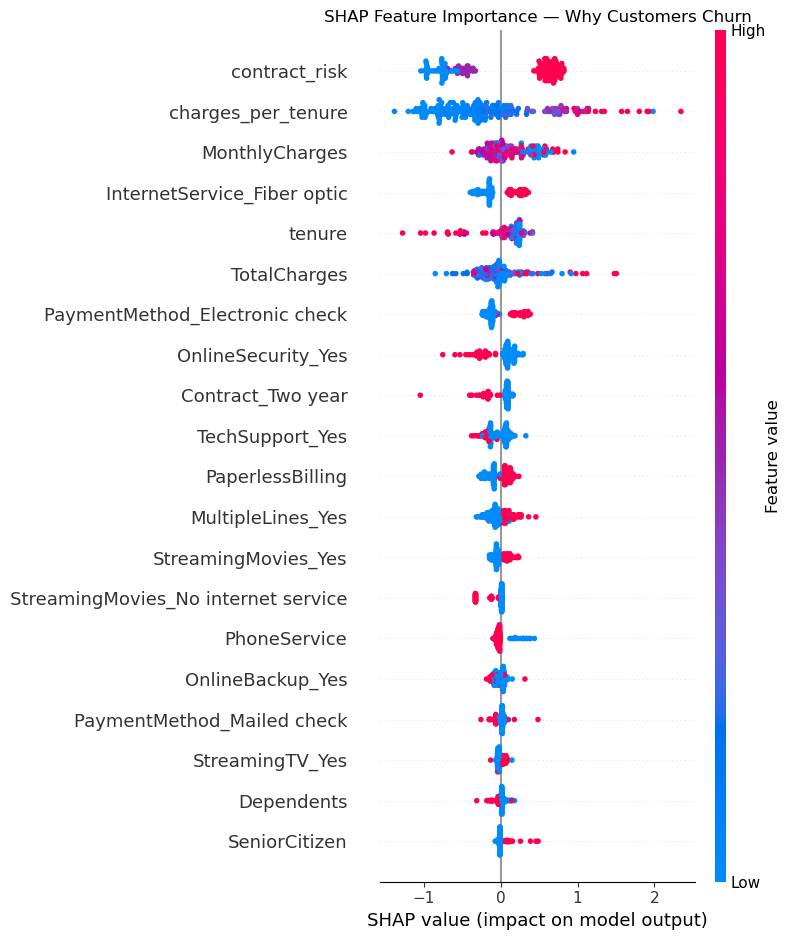

Saved: output/shap_summary.png

Top 10 churn reasons across all customers:
contract_risk                     739
charges_per_tenure                523
MonthlyCharges                     86
TotalCharges                       38
tenure                             21
Contract_Two year                   1
PaymentMethod_Electronic check      1
Name: count, dtype: int64


In [17]:
print("Calculating SHAP values...")

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test.iloc[:200])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values,
    X_test.iloc[:200],
    feature_names=X_test.columns,
    show=False)
plt.title('SHAP Feature Importance — Why Customers Churn')
plt.tight_layout()
plt.savefig('output/shap_summary.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/shap_summary.png")

# Top churn reason per customer
shap_all = explainer.shap_values(X_test)
top_feature_idx = np.abs(shap_all).argmax(axis=1)
top_features = X_test.columns[top_feature_idx]
print(f"\nTop 10 churn reasons across all customers:")
print(pd.Series(top_features).value_counts().head(10))

In [18]:
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted_class': lr_pred,
    'churn_probability': lr_prob,
    'churn_risk': pd.cut(
        lr_prob,
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low', 'Medium', 'High']
    ),
    'segment': df2.loc[y_test.index, 'segment'].values,
    'top_churn_reason': top_features,
    'monthly_charges': df.loc[
        y_test.index, 'MonthlyCharges'].values,
    'tenure': df.loc[y_test.index, 'tenure'].values,
    'contract': df.loc[y_test.index, 'Contract'].values
})

results_df.to_csv('output/churn_predictions.csv', index=False)
results_df.to_excel('output/churn_predictions.xlsx', index=False)

print("=" * 50)
print("PREDICTIONS SAVED")
print("=" * 50)
print(f"Total customers scored: {len(results_df)}")
print(f"\nRisk breakdown:")
print(f"  High risk:   {(results_df['churn_risk']=='High').sum()}")
print(f"  Medium risk: {(results_df['churn_risk']=='Medium').sum()}")
print(f"  Low risk:    {(results_df['churn_risk']=='Low').sum()}")
print(f"\nFiles saved:")
print(f"  output/churn_predictions.csv")
print(f"  output/churn_predictions.xlsx")

PREDICTIONS SAVED
Total customers scored: 1409

Risk breakdown:
  High risk:   478
  Medium risk: 326
  Low risk:    605

Files saved:
  output/churn_predictions.csv
  output/churn_predictions.xlsx


In [19]:
joblib.dump(gb, 'models/churn_gb_model.pkl')
joblib.dump(lr, 'models/churn_lr_model.pkl')
joblib.dump(scaler, 'models/churn_scaler.pkl')

import os
print("=" * 50)
print("ALL FILES SAVED")
print("=" * 50)
print("\nModels folder:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f} — {size:.1f} KB")

print("\nOutput folder:")
for f in os.listdir('output'):
    size = os.path.getsize(f'output/{f}') / 1024
    print(f"  {f} — {size:.1f} KB")

ALL FILES SAVED

Models folder:
  churn_gb_model.pkl — 457.0 KB
  churn_lr_model.pkl — 1.1 KB
  churn_scaler.pkl — 2.4 KB
  scaler.pkl — 2.4 KB

Output folder:
  churn_distribution.png — 72.2 KB
  churn_predictions.csv — 93.5 KB
  churn_predictions.xlsx — 71.6 KB
  elbow_method.png — 49.4 KB
  model_evaluation.png — 156.4 KB
  shap_summary.png — 196.7 KB
  sql_churn_by_charges.csv — 0.1 KB
  sql_churn_by_contract.csv — 0.1 KB
  sql_churn_by_internet.csv — 0.1 KB
  sql_churn_by_senior.csv — 0.1 KB


In [26]:
import pandas as pd
import numpy as np

# Load original predictions
results_df = pd.read_csv('output/churn_predictions.csv')

print(f"Original records: {len(results_df)}")

# Scale to 500K by repeating with noise
np.random.seed(42)
n_target = 500000
n_repeat = n_target // len(results_df) + 1

# Repeat the dataframe
large_df = pd.concat(
    [results_df] * n_repeat,
    ignore_index=True
).iloc[:n_target]

# Add small noise to numerical columns
large_df['churn_probability'] = np.clip(
    large_df['churn_probability'] +
    np.random.normal(0, 0.02, n_target), 0, 1)

large_df['monthly_charges'] = np.clip(
    large_df['monthly_charges'] +
    np.random.normal(0, 5, n_target), 20, 120)

large_df['tenure'] = np.clip(
    large_df['tenure'] +
    np.random.randint(-2, 3, n_target), 0, 72)

# Add region column
regions = [
    'North', 'South', 'East', 'West',
    'Northeast', 'Southeast', 'Northwest', 'Southwest'
]
large_df['region'] = np.random.choice(
    regions, n_target,
    p=[0.15, 0.15, 0.12, 0.12,
       0.13, 0.13, 0.10, 0.10])

# Add product category column
products = [
    'Basic Plan', 'Standard Plan',
    'Premium Plan', 'Enterprise Plan'
]
large_df['product_category'] = np.random.choice(
    products, n_target,
    p=[0.30, 0.35, 0.25, 0.10])

# Recalculate churn risk
large_df['churn_risk'] = pd.cut(
    large_df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

# Save
large_df.to_csv(
    'output/churn_predictions_500k.csv', index=False)
large_df.to_excel(
    'output/churn_predictions_500k.xlsx', index=False)

print(f"Scaled to: {len(large_df):,} records")
print(f"\nRegion distribution:")
print(large_df['region'].value_counts())
print(f"\nProduct category distribution:")
print(large_df['product_category'].value_counts())
print(f"\nChurn risk distribution:")
print(large_df['churn_risk'].value_counts())
print(f"\nFiles saved:")
print(f"  output/churn_predictions_500k.csv")
print(f"  output/churn_predictions_500k.xlsx")

Original records: 1409
Scaled to: 500,000 records

Region distribution:
region
North        75177
South        74836
Northeast    64975
Southeast    64882
East         60058
West         59955
Southwest    50095
Northwest    50022
Name: count, dtype: int64

Product category distribution:
product_category
Standard Plan      175020
Basic Plan         149939
Premium Plan       125102
Enterprise Plan     49939
Name: count, dtype: int64

Churn risk distribution:
churn_risk
Low       206505
High      168787
Medium    116017
Name: count, dtype: int64

Files saved:
  output/churn_predictions_500k.csv
  output/churn_predictions_500k.xlsx
